here we use alephBERT
Why Unlike classical models (like Word2Vec), BERT uses Contextual Embeddings. In the NLI task, the meaning of a word in "assumption" depends entirely on its context in "hypothesis".

Attention mechanism: The model performs Self-Attention which allows it to identify long-term relationships between sentence parts, which is critical in Hebrew where the syntax can be complex.

Classification Head: Above the BERT layer we added a Linear layer with a Softmax function that maps the [CLS] vector into three classes (Entailment, Contradiction, Neutral).


We used the parapemters from the runnning the find hyperparameters.
We used early stoping to not compute extra for no use and to prevent over fitting.
We saved the models


In [1]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
from datasets import load_dataset
from transformers import EarlyStoppingCallback

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report

# -----------------------
# A) Load your JSONL file
# -----------------------
# This reads each JSON line as one training example.
data_files = {
    "train": "/content/drive/MyDrive/nlp_pro2/data_sets/use_part/train.jsonl",
    "validation": "/content/drive/MyDrive/nlp_pro2/data_sets/use_part/val.jsonl",
    "test": "/content/drive/MyDrive/nlp_pro2/data_sets/use_part/test.jsonl",
}
ds = load_dataset("json", data_files=data_files)


# -----------------------
# B) Label mapping
# -----------------------
label_list = ["entailment", "contradiction", "neutral"]
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for l, i in label2id.items()}

def add_label_id(example):
    example["label"] = label2id[example["label"]]
    return example

ds = ds.map(add_label_id)

# -----------------------
# C) Tokenizer (AlephBERT)
# -----------------------
# Tokenizer turns Hebrew text into numbers the model understands.
model_name = "onlplab/alephbert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# -----------------------
# D) Model for 3-class classification - MOVED HERE
# -----------------------
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)

# Ensure PAD exists (some checkpoints are missing it)
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({"pad_token": "[PAD]"})

# If tokenizer has more tokens than model embeddings, resize
if len(tokenizer) != model.config.vocab_size:
    model.resize_token_embeddings(len(tokenizer))

print("AFTER FIX -> model vocab_size:", model.config.vocab_size, "tokenizer len:", len(tokenizer))
print("pad token:", tokenizer.pad_token, "pad_id:", tokenizer.pad_token_id)


def tokenize_pair(example):
    return tokenizer(
        example["translation1"],
        example["translation2"],
        truncation=True,
        max_length=256,
    )

ds_tok = ds.map(tokenize_pair, batched=False)
cols = ["input_ids", "attention_mask", "label"]
ds_tok = ds_tok.remove_columns([c for c in ds_tok["train"].column_names if c not in cols])

def find_bad_example(split="train", limit=10000):
    emb_size = model.get_input_embeddings().weight.shape[0]
    ds_split = ds_tok[split]
    n = min(limit, len(ds_split))

    for i in range(n):
        ids = ds_split[i]["input_ids"]
        mx = max(ids)
        mn = min(ids)
        if mn < 0 or mx >= emb_size:
            print("BAD EXAMPLE FOUND!")
            print("split:", split, "index:", i)
            print("min_id:", mn, "max_id:", mx, "emb_size:", emb_size)
            print("translation1:", ds[split][i]["translation1"])
            print("translation2:", ds[split][i]["translation2"])
            print("input_ids:", ids[:80], "...")
            return i

    print(f"No bad examples found in first {n} rows of {split}")
    return None

find_bad_example("train")
find_bad_example("validation")
find_bad_example("test")


# This pads batches nicely (so all examples in a batch have same length).
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


# -----------------------
# E) Metrics (what “results” you’ll see)
# -----------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "macro_f1": macro_f1}

# -----------------------
# F) Training settings
# -----------------------
args = TrainingArguments(
    output_dir="alephbert_final_fulltrain",
    learning_rate=3.76690649380035e-05,
    warmup_ratio=0.09881535889557601,
    weight_decay=0.039841378722297226,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none",
    fp16=True,# האצה של פי 2-3 ב-A100
)


# -----------------------
# G) Trainer (does the training loop)
# -----------------------
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_tok["train"],
    eval_dataset=ds_tok["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2, early_stopping_threshold=0.02)]
)

# -----------------------
# H) Train + Evaluate
# -----------------------
trainer.train()

print("\nFINAL TEST RESULTS:")
test_out = trainer.predict(ds_tok["test"])
test_logits = test_out.predictions
test_labels = test_out.label_ids
test_preds = np.argmax(test_logits, axis=-1)

print(classification_report(test_labels, test_preds, target_names=label_list, digits=4))
print("Confusion matrix (rows=true, cols=pred) label order:", label_list)
print(confusion_matrix(test_labels, test_preds))

# -----------------------
# I) Per-genre results (nice for your report)
# -----------------------
test_genres = ds["test"]["genre"]
print("\nPer-genre macro-F1:")
for g in sorted(set(test_genres)):
    idx = [i for i, gg in enumerate(test_genres) if gg == g]
    g_labels = test_labels[idx]
    g_preds = test_preds[idx]
    g_f1 = f1_score(g_labels, g_preds, average="macro")
    print(f"  {g:12s} n={len(idx):4d} macro_f1={g_f1:.4f}")

# -----------------------
# J) Save the model (required deliverable)
# -----------------------
trainer.save_model("/content/drive/MyDrive/nlp_pro2/saved/alephbert_nli_full_best_early_stopping")
tokenizer.save_pretrained("/content/drive/MyDrive/nlp_pro2/saved/alephbert_nli_full_best_early_stopping")
print('saving the modal!')

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/99999 [00:00<?, ? examples/s]

Map:   0%|          | 0/21429 [00:00<?, ? examples/s]

...

No bad examples found in first 10000 rows of train
No bad examples found in first 10000 rows of validation
No bad examples found in first 10000 rows of test


/tmp/ipython-input-3469870106.py:146: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.764100,0.740838,0.686220,0.685512
2,0.648500,0.691008,0.717299,0.717306
3,0.443700,0.792399,0.716179,0.716090
4,0.283500,0.942374,0.705866,0.706557



FINAL TEST RESULTS:


               precision    recall  f1-score   support

   entailment     0.7019    0.7606    0.7301      7211
contradiction     0.7805    0.6694    0.7207      7114
      neutral     0.6724    0.7111    0.6912      7104

     accuracy                         0.7139     21429
    macro avg     0.7183    0.7137    0.7140     21429
 weighted avg     0.7182    0.7139    0.7141     21429

Confusion matrix (rows=true, cols=pred) label order: ['entailment', 'contradiction', 'neutral']
[[5485  531 1195]
 [1086 4762 1266]
 [1244  808 5052]]

Per-genre macro-F1:
  fiction      n=5202 macro_f1=0.7011
  government   n=5439 macro_f1=0.7397
  letters      n= 139 macro_f1=0.8124
  nineeleven   n= 131 macro_f1=0.6746
  oup          n= 138 macro_f1=0.6960
  slate        n=5018 macro_f1=0.6809
  travel       n=5362 macro_f1=0.7300
saving the modal!


# Evaluation

**Confusion Matrix**

In [17]:
# finding fp/fn per label
import numpy as np

labels = ["entailment","contradiction","neutral"]
for i, name in enumerate(labels):
    fp = np.sum((test_preds == i) & (test_labels != i))
    fn = np.sum((test_preds != i) & (test_labels == i))
    tp = np.sum((test_preds == i) & (test_labels == i))
    tn = np.sum((test_preds != i) & (test_labels != i))
    print(f"{name:13s} TP={tp:3d} FP={fp:3d} FN={fn:3d} TN={tn:3d}")

entailment    TP=5485 FP=2330 FN=1726 TN=11888
contradiction TP=4762 FP=1339 FN=2352 TN=12976
neutral       TP=5052 FP=2461 FN=2052 TN=11864


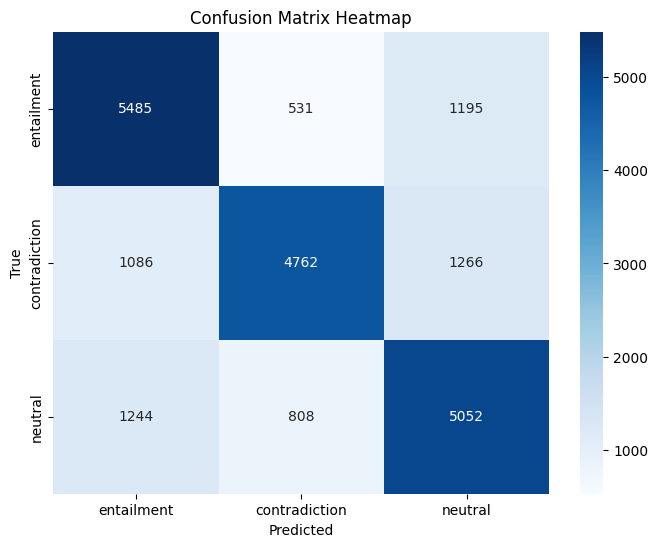

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# יצירת Heatmap למטריצת הבלבול
plt.figure(figsize=(8, 6))
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_list, yticklabels=label_list)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

**AUC-ROC**

In [5]:
import numpy as np
from sklearn.metrics import roc_auc_score
from scipy.special import softmax

probs = softmax(test_logits, axis=1)  # shape: (N, 3)

# One-vs-Rest ROC AUC
auc_macro_ovr = roc_auc_score(test_labels, probs, multi_class="ovr", average="macro")
auc_weighted_ovr = roc_auc_score(test_labels, probs, multi_class="ovr", average="weighted")

print("ROC-AUC macro (OvR):", auc_macro_ovr)
print("ROC-AUC weighted (OvR):", auc_weighted_ovr)

ROC-AUC macro (OvR): 0.8743828157759618
ROC-AUC weighted (OvR): 0.874447248336199


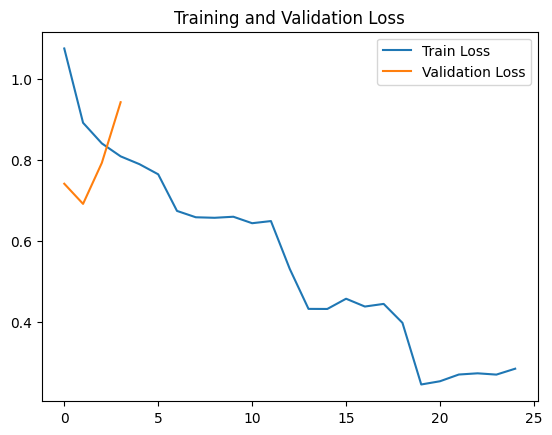

In [4]:
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]

plt.plot(train_loss, label='Train Loss')
plt.plot(eval_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

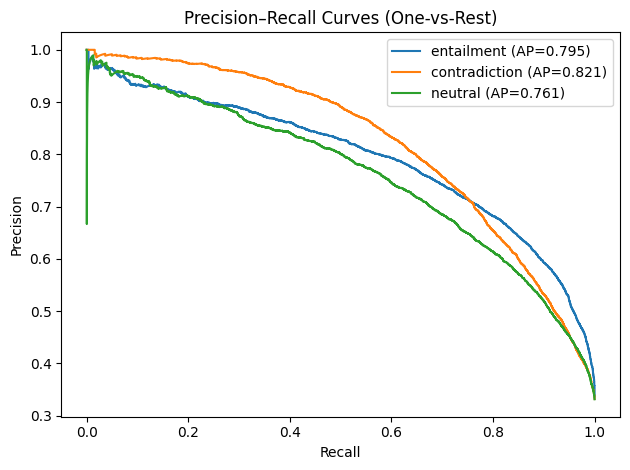

In [6]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

y_true_bin = label_binarize(test_labels, classes=[0,1,2])  # shape (N,3)

plt.figure()
for i, name in enumerate(label_list):
    prec, rec, _ = precision_recall_curve(y_true_bin[:, i], probs[:, i])
    ap = average_precision_score(y_true_bin[:, i], probs[:, i])
    plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")

plt.title("Precision–Recall Curves (One-vs-Rest)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd

inv_id2label = {0:"entailment", 1:"contradiction", 2:"neutral"}

rows = []
for i in range(len(test_labels)):
    true_id = int(test_labels[i])
    pred_id = int(test_preds[i])
    if true_id != pred_id:
        rows.append({
            "i": i,
            "genre": ds["test"][i]["genre"],
            "t1": ds["test"][i]["translation1"],
            "t2": ds["test"][i]["translation2"],
            "true": inv_id2label[true_id],
            "pred": inv_id2label[pred_id],
            "pred_conf": float(probs[i, pred_id]),
            "true_conf": float(probs[i, true_id]),
            "margin": float(probs[i, pred_id] - probs[i, true_id]),
        })

err_df = pd.DataFrame(rows)
print("Total errors:", len(err_df))

Total errors: 6130


In [12]:
print(f"% of mistakes: {6130/21429}")

% of mistakes: 0.28606094544775773


Examples:

In [13]:
print("Total errors:", len(err_df))
err_df.head(3)

Total errors: 6130


,i,genre,t1,t2,true,pred,pred_conf,true_conf,margin
0,0,fiction,מזל בשביל דרו שלא היו עדים נוספים עכשיו; הדמיו...,לדרו היתה תקופה של מזל רע כאשר היו לפחות תריסר...,contradiction,neutral,0.480501,0.311217,0.169285
1,1,fiction,"אבל שפטתי שחשוב לא לבזבז זמן."" וכמה שיותר בתמצ...",הוא סיפר סיפור ארוך מאוד על החוויות האחרונות שלו.,contradiction,neutral,0.597293,0.061797,0.535496
2,5,letters,אנחנו מגיעים לילדים -- במיוחד אלה משכונות מצוק...,אנחנו רוצים לעזור יותר לאנשים הנזקקים,entailment,neutral,0.720662,0.256709,0.463953


In [14]:
print("\nTop 5 confidently wrong:")
display(err_df.sort_values("pred_conf", ascending=False).head(5))

print("\nTop 5 ambiguous (small margin):")
display(err_df.sort_values("margin", ascending=True).head(5))



Top 5 confidently wrong:


,i,genre,t1,t2,true,pred,pred_conf,true_conf,margin
1883,6410,government,החלק השני דן בתפקיד של הטכנולוגיה המתקדמת והשפ...,טכנולוגיה לא הוזכרה בחלק הראשון.,neutral,contradiction,0.989589,0.006786,0.982803
36,101,slate,"לדעתם, זה היה עוזר.","לדעתי, זה לא היה עוזר.",neutral,contradiction,0.989484,0.006906,0.982578
5573,19428,travel,כוח דה פקטו הופעל על ידי המשפחה החזקה ביותר מב...,למשפחות החלשות לא הייתה שום כוח משמעותי.,neutral,contradiction,0.988950,0.008564,0.980386
1061,3600,travel,אבל אתר התיירות הפופולרי ביותר הוא ארמון טופקא...,הסולטנים העות'מאנים לא התעניינו בתיירים.,neutral,contradiction,0.988436,0.009085,0.979350
3592,12517,travel,"מומלץ לבקר בפריז בתחילת הקיץ ובסתיו, וכנסיית ה...",לא שווה לבקר בפריז בחורף או באביב.,neutral,contradiction,0.988067,0.009361,0.978706



Top 5 ambiguous (small margin):


,i,genre,t1,t2,true,pred,pred_conf,true_conf,margin
5001,17479,government,"זה בערך 8,500 מקרים בשנה.",יש מעל שמונת אלפים תיקי סיוע משפטי בשנה.,neutral,entailment,0.415157,0.415106,0.000051
439,1571,government,דואר חשבונות/תשלומים כולל גם את דואר התשלומים ...,דואר תשלום הוא לעתים קרובות דואר ביתי.,entailment,neutral,0.417833,0.417680,0.000153
1018,3437,travel,"הר פוג'י, לפי השמועות, נוצר כערמת חול שהשאירו ...",לעתים קרובות נאמר שפוג'י נוצר מערימות חול שעוב...,entailment,contradiction,0.372317,0.371794,0.000522
746,2566,slate,הסטנדרט היחיד שלפיו ארגוני חדשות מרגישים בנוח ...,ארגוני חדשות חושבים על מדיניות במונחים של מה ע...,entailment,neutral,0.454010,0.453346,0.000665
2082,7171,fiction,האפי האפי הופיעה על מדפי החנויות מלווה בקמפיין...,חנויות הוסיפו את למדפיהם.,entailment,neutral,0.478920,0.478219,0.000701


There are 2 ways to check the mistakes:


1.   by the confidence - where the confidence is the the biggest
2.   to check by labels - to see where the model most mistaken



# Option 1

In [18]:
target = "neutral"
target_id = labels.index(target)

pred_neutral_idx = np.where(test_preds == target_id)[0]
avg_conf_pred_neutral = probs[pred_neutral_idx, target_id].mean()
print("Avg confidence when predicting neutral:", avg_conf_pred_neutral)

true_neutral_idx = np.where(test_labels == target_id)[0]
avg_conf_true_neutral = probs[true_neutral_idx, target_id].mean()
print("Avg confidence on TRUE neutral examples:", avg_conf_true_neutral)

fp_idx = np.where((test_preds == target_id) & (test_labels != target_id))[0]
fn_idx = np.where((test_preds != target_id) & (test_labels == target_id))[0]
avg_conf_fp = probs[fp_idx, target_id].mean() if len(fp_idx) else float("nan")
avg_conf_fn = probs[fn_idx, target_id].mean() if len(fn_idx) else float("nan")
print("Avg P(neutral) for FP neutral:", avg_conf_fp)
print("Avg P(neutral) for FN neutral:", avg_conf_fn)

avg_wrong_conf_fn = probs[fn_idx, test_preds[fn_idx]].mean() if len(fn_idx) else float("nan")
print("Avg confidence in the WRONG predicted label (on FN neutral):", avg_wrong_conf_fn)

Avg confidence when predicting neutral: 0.75500494
Avg confidence on TRUE neutral examples: 0.63239956
Avg P(neutral) for FP neutral: 0.6674691
Avg P(neutral) for FN neutral: 0.22556345
Avg confidence in the WRONG predicted label (on FN neutral): 0.68087775


In [19]:
# option 1
import numpy as np
import pandas as pd
from scipy.special import softmax

label_list = ["entailment", "contradiction", "neutral"]
id2label = {i:l for i,l in enumerate(label_list)}

# test_logits, test_labels, test_preds must already exist
probs = softmax(test_logits, axis=1)  # shape (N, 3)

In [20]:
# option 1 exapmls
# Top 15 confident wrong predictions
top_conf_errors = err_df.sort_values("pred_conf", ascending=False).head(15)

for _, r in top_conf_errors.iterrows():
    print("\n" + "="*80)
    print(f"Index {r['i']} | genre={r['genre']}")
    print(f"TRUE={r['true']} | PRED={r['pred']} | pred_conf={r['pred_conf']:.3f} | true_conf={r['true_conf']:.3f}")
    print("t1:", r["t1"])
    print("t2:", r["t2"])


Index 6410 | genre=government
TRUE=neutral | PRED=contradiction | pred_conf=0.990 | true_conf=0.007
t1: החלק השני דן בתפקיד של הטכנולוגיה המתקדמת והשפעתה על שינויים משמעותיים שהתרחשו וממשיכים להתרחש במערכות התשלום.
t2: טכנולוגיה לא הוזכרה בחלק הראשון.

Index 101 | genre=slate
TRUE=neutral | PRED=contradiction | pred_conf=0.989 | true_conf=0.007
t1: לדעתם, זה היה עוזר.
t2: לדעתי, זה לא היה עוזר.

Index 19428 | genre=travel
TRUE=neutral | PRED=contradiction | pred_conf=0.989 | true_conf=0.009
t1: כוח דה פקטו הופעל על ידי המשפחה החזקה ביותר מבחינה צבאית וכלכלית.
t2: למשפחות החלשות לא הייתה שום כוח משמעותי.

Index 3600 | genre=travel
TRUE=neutral | PRED=contradiction | pred_conf=0.988 | true_conf=0.009
t1: אבל אתר התיירות הפופולרי ביותר הוא ארמון טופקאפי, ביתם של הסולטנים העות'מאנים, שם עושר האוצר הקיסרי והתככים של ההרמון מושכים רבבות מבקרים מדי שנה.
t2: הסולטנים העות'מאנים לא התעניינו בתיירים.

Index 12517 | genre=travel
TRUE=neutral | PRED=contradiction | pred_conf=0.988 | true_conf=0.0

In [21]:
# option 1 to check if negative with the used of (no/not) in one t1 and not the other is the coes of the the high conf
# Many high-confidence errors contain negation in only one sentence, suggesting the model overreacts to negation cues
import re

NEG_RE = re.compile(r"\b(לא|אין|בלי|אף|מעולם)\b")

def has_neg(s):
    return bool(NEG_RE.search(str(s)))

def negation_flip(t1, t2):
    return has_neg(t1) ^ has_neg(t2)  # True if only one has negation

top = err_df.sort_values("pred_conf", ascending=False).head(30).copy()
top["neg_flip"] = top.apply(lambda r: negation_flip(r["t1"], r["t2"]), axis=1)

print("How many of top 30 errors have negation flip:", top["neg_flip"].sum())
top[top["neg_flip"]][["true","pred","pred_conf","t1","t2"]].head(5)

How many of top 30 errors have negation flip: 25


,true,pred,pred_conf,t1,t2
1883,neutral,contradiction,0.989589,החלק השני דן בתפקיד של הטכנולוגיה המתקדמת והשפ...,טכנולוגיה לא הוזכרה בחלק הראשון.
36,neutral,contradiction,0.989484,"לדעתם, זה היה עוזר.","לדעתי, זה לא היה עוזר."
5573,neutral,contradiction,0.988950,כוח דה פקטו הופעל על ידי המשפחה החזקה ביותר מב...,למשפחות החלשות לא הייתה שום כוח משמעותי.
1061,neutral,contradiction,0.988436,אבל אתר התיירות הפופולרי ביותר הוא ארמון טופקא...,הסולטנים העות'מאנים לא התעניינו בתיירים.
3592,neutral,contradiction,0.988067,"מומלץ לבקר בפריז בתחילת הקיץ ובסתיו, וכנסיית ה...",לא שווה לבקר בפריז בחורף או באביב.


In [22]:
# החלת הפונקציה על כל הטעויות
err_df["neg_flip"] = err_df.apply(lambda r: negation_flip(r["t1"], r["t2"]), axis=1)

# חישוב הכמות הכוללת והאחוז מתוך כלל הטעויות
total_neg_flip_errors = err_df["neg_flip"].sum()
percent_of_errors = (total_neg_flip_errors / len(err_df)) * 100

print(f"סה''כ טעויות עם 'היפוך שלילה': {total_neg_flip_errors}")
print(f"אחוז מתוך כלל הטעויות: {percent_of_errors:.2f}%")

# בדיקה: באילו מחלקות המודל הכי מתבלבל כשיש שלילה?
neg_error_dist = err_df[err_df["neg_flip"]].groupby(['true', 'pred']).size().unstack(fill_value=0)
print("\nהתפלגות טעויות שלילה (אמת מול חיזוי):")
display(neg_error_dist)

סה''כ טעויות עם 'היפוך שלילה': 1231
אחוז מתוך כלל הטעויות: 20.08%

התפלגות טעויות שלילה (אמת מול חיזוי):


pred,contradiction,entailment,neutral
true,,,
contradiction,0,183,266
entailment,163,0,174
neutral,282,163,0


In [23]:
# option 1 to check if sentences include dates, the model may ignore them and this is the coes of the the high conf
# Many high-confidence errors contain negation in only one sentence, suggesting the model overreacts to negation cues
import re

TEMP_RE = re.compile(r"\b(אתמול|מחר|היום|השבוע|חודש|שנה|יום|לילה|בוקר|ערב|שני|שלישי|רביעי|חמישי|שישי|שבת|סוף\s*השבוע)\b")

def has_neg(s):
    return bool(TEMP_RE.search(str(s)))

def negation_flip(t1, t2):
    return has_neg(t1) ^ has_neg(t2)  # True if only one has negation

top = err_df.sort_values("pred_conf", ascending=False).head(30).copy()
top["neg_flip"] = top.apply(lambda r: negation_flip(r["t1"], r["t2"]), axis=1)

print("How many of top 30 errors have negation flip:", top["neg_flip"].sum())
top[top["neg_flip"]][["true","pred","pred_conf","t1","t2"]].head(5)

How many of top 30 errors have negation flip: 1


,true,pred,pred_conf,t1,t2
1061,neutral,contradiction,0.988436,אבל אתר התיירות הפופולרי ביותר הוא ארמון טופקא...,הסולטנים העות'מאנים לא התעניינו בתיירים.


In [26]:
# החלת הפונקציה על כל הטעויות
err_df["neg_flip"] = err_df.apply(lambda r: negation_flip(r["t1"], r["t2"]), axis=1)

# חישוב הכמות הכוללת והאחוז מתוך כלל הטעויות
total_neg_flip_errors = err_df["neg_flip"].sum()
percent_of_errors = (total_neg_flip_errors / len(err_df)) * 100

print(f"סה''כ טעויות עם תאריכים': {total_neg_flip_errors}")
print(f"אחוז מתוך כלל הטעויות: {percent_of_errors:.2f}%")

# בדיקה: באילו מחלקות המודל הכי מתבלבל כשיש שלילה?
neg_error_dist = err_df[err_df["neg_flip"]].groupby(['true', 'pred']).size().unstack(fill_value=0)
print("\nהתפלגות טעויות שלילה (אמת מול חיזוי):")
display(neg_error_dist)

סה''כ טעויות עם תאריכים': 299
אחוז מתוך כלל הטעויות: 4.88%

התפלגות טעויות שלילה (אמת מול חיזוי):


pred,contradiction,entailment,neutral
true,,,
contradiction,0,49,73
entailment,21,0,52
neutral,52,52,0


In [33]:
# option 1 to check if sentences include numbers, the model may ignore them and this is the coes of the the high conf

NUM_RE = re.compile(r"\b(\d+|אחד|אחת|שניים|שתיים|שלושה|שלוש|ארבע|חמש|שש|שבע|שמונה|תשע|עשר|מאה|אלף|מיליון|אחוז)\b")

def has_number(s):
    return bool(NUM_RE.search(str(s)))

top["has_num"] = top.apply(lambda r: has_number(r["t1"]) or has_number(r["t2"]), axis=1)
print("How many of top 30 errors have numbers:", top["has_num"].sum())
top[top["has_num"]][["true","pred","pred_conf","t1","t2"]].head(5)

How many of top 30 errors have numbers: 2


,true,pred,pred_conf,t1,t2
2790,neutral,contradiction,0.983217,המחקר של שוורץ (1993) בדק את הקשר בין חשיפה ל-...,המחקר בדק את הקשר בין חשיפה ל-10 לבין שכיחות ש...
5000,neutral,contradiction,0.981261,הקל הביט בקא'דאן והעניק לו אחד מחיוכיו המעוותי...,קאדאן מעולם לא פגש את הקאל.


In [35]:
# החלת הזיהוי על כל מערך הטעויות
err_df["has_num"] = err_df.apply(lambda r: has_number(r["t1"]) or has_number(r["t2"]), axis=1)

# חישוב כמות ואחוזים
total_num_errors = err_df["has_num"].sum()
percent_of_errors = (total_num_errors / len(err_df)) * 100

print(f"סה''כ טעויות המכילות מספרים/כמויות: {total_num_errors}")
print(f"אחוז מתוך כלל הטעויות: {percent_of_errors:.2f}%")

#יקה: באילו מחלקות המודל הכי מתבלבל כשיש מספר ?
num_error_dist = err_df[err_df["has_num"]].groupby(['true', 'pred']).size().unstack(fill_value=0)
print("\nהתפלגות טעויות מספר (אמת מול חיזוי):")
display(num_error_dist)

סה''כ טעויות המכילות מספרים/כמויות: 1547
אחוז מתוך כלל הטעויות: 25.24%

התפלגות טעויות מספר (אמת מול חיזוי):


pred,contradiction,entailment,neutral
true,,,
contradiction,0,298,321
entailment,128,0,295
neutral,227,278,0


In [38]:
# option 1
# In several cases the model predicts entailment even though sentence 2 adds details not stated in sentence 1.
# This suggests the model relies on common-sense assumptions rather than strict logical entailment.
# so we check if

guess_df = err_df[(err_df["true"]=="neutral") & (err_df["pred"]=="entailment")].copy()
guess_df = guess_df.sort_values("pred_conf", ascending=False).head(15)

print(f'amount of gussing: {len(guess_df)}')
for _, r in guess_df.iterrows():
    print("\n" + "="*70)
    print(f"TRUE={r['true']} PRED={r['pred']} conf={r['pred_conf']:.3f}")
    print("t1:", r["t1"])
    print("t2:", r["t2"])

amount of gussing: 15

TRUE=neutral PRED=entailment conf=0.967
t1: היא לא ידעה על זה, אמר קארי על עסקת הסמים.
t2: קארי אמרה שהיא לא ידעה על עסקת הסמים.

TRUE=neutral PRED=entailment conf=0.965
t1: לידו נמצא אולם אבוט, אחוזה ג'ורג'יאנית יפה שבה שוכנים כיום גלריית האמנות אולם אבוט ומוזיאון לייקלנד לייף.
t2: יש אולם באולם אבוט.

TRUE=neutral PRED=entailment conf=0.963
t1: ומה עם התכנית הזו שלך? למה לאון הגיע אליו איתה?
t2: מדוע לאון ניגש אליו עם התוכנית שלך?

TRUE=neutral PRED=entailment conf=0.963
t1: זה לא יהיה יוצא דופן.
t2: זה לא יהיה יוצא דופן.

TRUE=neutral PRED=entailment conf=0.961
t1: כן אדוני, אני ווילאם. 57 "וגברת אינגלתורפ ניגשה לחלון וקראה לכם, לא כך?"
t2: גברת אינגלתורפ פתחה את החלון כדי לקרוא.

TRUE=neutral PRED=entailment conf=0.960
t1: חשבתי שזה מתאים גם לעונת החגים וגם לניתוח שלאחר מעשה של תיק תעריפי הדואר.
t2: חשבתי שזה מתאים גם לעונת החגים וגם למקרה תעריף הדואר לאחר מעשה.

TRUE=neutral PRED=entailment conf=0.960
t1: המושלת וויטמן ואני מאמינים שניתן להגיע להסכמה בקרוב י

In [40]:
# option 1
# Maybe the label is wrong
# 2 ways to ckeck this:
# number 1 if confidence > 0.95
noise_candidates = err_df[err_df["pred_conf"] > 0.95].sort_values("pred_conf", ascending=False).head(10)
print(f'amount of noise candidates: {len(noise_candidates)}')

for _, r in noise_candidates.iterrows():
    print("\n" + "="*70)
    print(f"TRUE={r['true']} PRED={r['pred']} conf={r['pred_conf']:.3f} genre={r['genre']}")
    print("t1:", r["t1"])
    print("t2:", r["t2"])

amount of noise candidates: 10

TRUE=neutral PRED=contradiction conf=0.990 genre=government
t1: החלק השני דן בתפקיד של הטכנולוגיה המתקדמת והשפעתה על שינויים משמעותיים שהתרחשו וממשיכים להתרחש במערכות התשלום.
t2: טכנולוגיה לא הוזכרה בחלק הראשון.

TRUE=neutral PRED=contradiction conf=0.989 genre=slate
t1: לדעתם, זה היה עוזר.
t2: לדעתי, זה לא היה עוזר.

TRUE=neutral PRED=contradiction conf=0.989 genre=travel
t1: כוח דה פקטו הופעל על ידי המשפחה החזקה ביותר מבחינה צבאית וכלכלית.
t2: למשפחות החלשות לא הייתה שום כוח משמעותי.

TRUE=neutral PRED=contradiction conf=0.988 genre=travel
t1: אבל אתר התיירות הפופולרי ביותר הוא ארמון טופקאפי, ביתם של הסולטנים העות'מאנים, שם עושר האוצר הקיסרי והתככים של ההרמון מושכים רבבות מבקרים מדי שנה.
t2: הסולטנים העות'מאנים לא התעניינו בתיירים.

TRUE=neutral PRED=contradiction conf=0.988 genre=travel
t1: מומלץ לבקר בפריז בתחילת הקיץ ובסתיו, וכנסיית האי מון-סן-מישל, על חוף נורמנדי, יכולה להיות קסומה לחלוטין בערפילים של דצמבר.
t2: לא שווה לבקר בפריז בחורף או באביב.



In [41]:
    # הגדרת סף הביטחון (Confidence Threshold)
threshold = 0.95

# סינון כל הטעויות שמעבר לסף
noise_df = err_df[err_df["pred_conf"] > threshold]

total_noise_candidates = len(noise_df)
percent_of_total_errors = (total_noise_candidates / len(err_df)) * 100

print(f"סה''כ מועמדים לרעש (ביטחון > {threshold}): {total_noise_candidates}")
print(f"אחוז מתוך כלל הטעויות: {percent_of_total_errors:.2f}%")

סה''כ מועמדים לרעש (ביטחון > 0.95): 181
אחוז מתוך כלל הטעויות: 2.95%


# optoin 2

In [42]:
# option 2
# to check which confusion happens the most:
import pandas as pd

# err_df must have columns: true, pred, pred_conf, genre, t1, t2
mistake_counts = (
    err_df.groupby(["true", "pred"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print(mistake_counts.to_string(index=False))

         true          pred  count
contradiction       neutral   1266
      neutral    entailment   1244
   entailment       neutral   1195
contradiction    entailment   1086
      neutral contradiction    808
   entailment contradiction    531


✅ Neutral is the “magnet” label — lots of things get pulled into neutral.

In [43]:
# option 2
# to inspect this type of error because its the most times the model got confused

true_label = "contradiction"
pred_label = "neutral"

subset = err_df[(err_df["true"] == true_label) & (err_df["pred"] == pred_label)].copy()

print("How many mistakes of this type:", len(subset))
print("Average confidence for this wrong prediction:", subset["pred_conf"].mean())

# show the top confident wrong ones (best for analysis)
subset = subset.sort_values("pred_conf", ascending=False).head(10)


How many mistakes of this type: 1266
Average confidence for this wrong prediction: 0.6722286795552873


In [44]:
import re
import pandas as pd
import numpy as np

# err_df should already contain: t1,t2,true,pred,genre,pred_conf,margin
# If not, build it as we did earlier.

NEG_RE = re.compile(r"\b(לא|אין|בלי|אף|מעולם)\b")
TEMP_RE = re.compile(r"\b(אתמול|מחר|היום|השבוע|שנה|שנת|חודש|יום|לילה|בוקר|ערב|שני|שלישי|רביעי|חמישי|שישי|שבת|סוף\s*השבוע)\b")
NUM_RE  = re.compile(r"\b(\d+|אחד|אחת|שניים|שתיים|שלושה|שלוש|ארבע|חמש|שש|שבע|שמונה|תשע|עשר|מאה|אלף|מיליון|אחוז)\b")
PRON_RE = re.compile(r"\b(הוא|היא|הם|הן|אותו|אותה|להם|להן|שלו|שלה|שלהם|שלהן)\b")

def tokenize_set(s):
    # Hebrew-only “word” tokens
    return set(re.findall(r"[\u0590-\u05FF]{2,}", s))

def jaccard(a, b):
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)

def detect_patterns(t1, t2, pred_conf=None, margin=None):
    tags = []

    # Negation flip: negation present in exactly one of the sentences
    n1 = bool(NEG_RE.search(t1))
    n2 = bool(NEG_RE.search(t2))
    if n1 ^ n2:
        tags.append("Negation flip")

    # Temporal
    if TEMP_RE.search(t1) or TEMP_RE.search(t2):
        tags.append("Temporal reasoning")

    # Numbers / quantifiers
    if NUM_RE.search(t1) or NUM_RE.search(t2):
        tags.append("Quantifiers / numbers")

    # Coreference / pronouns
    if PRON_RE.search(t1) or PRON_RE.search(t2):
        tags.append("Coreference / pronouns")

    # Lexical overlap trap: lots of shared words (tends to confuse neutral vs entailment)
    A = tokenize_set(t1)
    B = tokenize_set(t2)
    overlap = jaccard(A, B)
    if overlap >= 0.35:   # tune threshold if needed
        tags.append("Lexical overlap trap")

    # Ambiguity: model not confident (or small margin)
    if pred_conf is not None and pred_conf < 0.45:
        tags.append("Ambiguity")
    if margin is not None and abs(margin) < 0.10:
        if "Ambiguity" not in tags:
            tags.append("Ambiguity")

    return tags

# Apply to err_df
err_df = err_df.copy()
err_df["tags"] = err_df.apply(
    lambda r: detect_patterns(r["t1"], r["t2"], r.get("pred_conf"), r.get("margin")),
    axis=1
)

# Explode into one tag per row for analysis
exploded = err_df.explode("tags")
tag_counts = exploded["tags"].value_counts(dropna=True)
print(tag_counts)


tags
Coreference / pronouns    2448
Quantifiers / numbers     1547
Negation flip             1231
Ambiguity                  849
Temporal reasoning         387
Lexical overlap trap       375
Name: count, dtype: int64


on top is the top most commen errors.

In [45]:
coreference_errors = err_df[err_df['tags'].apply(lambda x: 'Coreference / pronouns' in x)].copy()

print("\nTop 5 errors with 'Coreference / pronouns' tag:")
for _, r in coreference_errors.head(5).iterrows():
    print("\n" + "="*80)
    print(f"Index {r['i']} | genre={r['genre']}")
    print(f"TRUE={r['true']} | PRED={r['pred']} | pred_conf={r['pred_conf']:.3f} | true_conf={r['true_conf']:.3f}")
    print("t1:", r["t1"])
    print("t2:", r["t2"])


Top 5 errors with 'Coreference / pronouns' tag:

Index 1 | genre=fiction
TRUE=contradiction | PRED=neutral | pred_conf=0.597 | true_conf=0.062
t1: אבל שפטתי שחשוב לא לבזבז זמן." וכמה שיותר בתמציתיות ובקצרה הוא פירט את החוויות של הימים האחרונים.
t2: הוא סיפר סיפור ארוך מאוד על החוויות האחרונות שלו.

Index 5 | genre=letters
TRUE=entailment | PRED=neutral | pred_conf=0.721 | true_conf=0.257
t1: אנחנו מגיעים לילדים -- במיוחד אלה משכונות מצוקה שבהן הסיכונים הם הגבוהים ביותר.
t2: אנחנו רוצים לעזור יותר לאנשים הנזקקים

Index 16 | genre=travel
TRUE=contradiction | PRED=neutral | pred_conf=0.914 | true_conf=0.068
t1: סקווש הפך למשחק מחבט פופולרי ומתקנים זמינים באופן נרחב.
t2: סקווש הוא המשחק השנוא ביותר.

Index 17 | genre=slate
TRUE=contradiction | PRED=entailment | pred_conf=0.559 | true_conf=0.099
t1: הסיפורים הפחותים במהדורה המלאה מטילים אור שגוי על הגדולים יותר.
t2: כל הסיפורים במהדורה השלמה הם גרועים באותה מידה.

Index 18 | genre=travel
TRUE=contradiction | PRED=neutral | pred_conf=0.569 

Now to check the error type per label

In [48]:
# 1. הגדרת רשימת זוגות הטעויות לפי הסדר שציינתם
error_pairs = [
    ('contradiction', 'neutral'),
    ('neutral', 'entailment'),
    ('entailment', 'neutral'),
    ('contradiction', 'entailment'),
    ('neutral', 'contradiction'),
    ('entailment', 'contradiction')
]

print("ניתוח התגיות המובילות לכל סוג טעות:")
print("="*50)

for t, p in error_pairs:
    # סינון ה-exploded dataframe עבור זוג תוויות ספציפי
    subset = exploded[(exploded['true'] == t) & (exploded['pred'] == p)]

    if not subset.empty:
        # ספירת התגיות בתוך הקבוצה הזו
        tag_dist = subset['tags'].value_counts()
        top_tag = tag_dist.idxmax()
        top_count = tag_dist.max()

        print(f"טעות מסוג: {t} -> {p}")
        print(f"  הסיבה (Tag) המובילה: {top_tag}")
        print(f"  כמות מקרים: {top_count}")
        print(f"  פירוט נוסף: {tag_dist.head(2).to_dict()}") # מראה את שתי התגיות המובילות
        print("-" * 30)

ניתוח התגיות המובילות לכל סוג טעות:
טעות מסוג: contradiction -> neutral
  הסיבה (Tag) המובילה: Coreference / pronouns
  כמות מקרים: 577
  פירוט נוסף: {'Coreference / pronouns': 577, 'Quantifiers / numbers': 321}
------------------------------
טעות מסוג: neutral -> entailment
  הסיבה (Tag) המובילה: Coreference / pronouns
  כמות מקרים: 469
  פירוט נוסף: {'Coreference / pronouns': 469, 'Quantifiers / numbers': 278}
------------------------------
טעות מסוג: entailment -> neutral
  הסיבה (Tag) המובילה: Coreference / pronouns
  כמות מקרים: 492
  פירוט נוסף: {'Coreference / pronouns': 492, 'Quantifiers / numbers': 295}
------------------------------
טעות מסוג: contradiction -> entailment
  הסיבה (Tag) המובילה: Coreference / pronouns
  כמות מקרים: 382
  פירוט נוסף: {'Coreference / pronouns': 382, 'Quantifiers / numbers': 298}
------------------------------
טעות מסוג: neutral -> contradiction
  הסיבה (Tag) המובילה: Coreference / pronouns
  כמות מקרים: 315
  פירוט נוסף: {'Coreference / pronouns'

now to check by gnere

In [47]:
top_conf = err_df.sort_values("pred_conf", ascending=False).head(30)
top_conf[["genre","true","pred","pred_conf","margin"]].head(10)

,genre,true,pred,pred_conf,margin
1883,government,neutral,contradiction,0.989589,0.982803
36,slate,neutral,contradiction,0.989484,0.982578
5573,travel,neutral,contradiction,0.988950,0.980386
1061,travel,neutral,contradiction,0.988436,0.979350
3592,travel,neutral,contradiction,0.988067,0.978706
2926,slate,neutral,contradiction,0.987799,0.978886
5998,fiction,neutral,contradiction,0.987463,0.977753
1890,government,neutral,contradiction,0.987227,0.977084
5811,government,entailment,contradiction,0.987149,0.983232
3518,travel,neutral,contradiction,0.986735,0.975795


---------------------------------------------------

Testing the model

In [16]:
from transformers import pipeline

# 1. טעינת המודל והטוקנייזר מהתיקייה ששמרת ב-Drive
model_path = "/content/drive/MyDrive/nlp_pro2/saved/alephbert_nli_full_best_early_stopping"
nli_predictor = pipeline("text-classification", model=model_path, tokenizer=model_path)

# 2. הגדרת דוגמה (Premise + Hypothesis)
# ב-NLI, אנחנו בדרך כלל מחברים את שני המשפטים עם תו מפריד (ה-Pipeline עושה זאת עבורך)
premise = "אני אוכל"
hypothesis = "אני רעב"

# 3. הרצה
result = nli_predictor(f"{premise} [SEP] {hypothesis}")

# הצגת התוצאה
print(f"Prediction: -- {result[0]['label']} --, Confidence: {result[0]['score']:.4f}")

Device set to use cuda:0


Prediction: -- contradiction --, Confidence: 0.9072
